<a href="https://colab.research.google.com/github/andressonsino/football-data-analysis/blob/main/huracan/notebooks/san_lorenzo_huracan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de partido — San Lorenzo vs Huracán
**Competición:** Liga Argentina — Clausura 2026  
**Fecha:** 2026  
**Resultado:** San Lorenzo 0 - 2 Huracán  
**Fuente de datos:** FBref  
**Autor:** Andrés  

---

## Estructura del notebook

1. Setup e importaciones  
2. Carga del dataset  
3. Limpieza  
4. EDA — Análisis exploratorio

> Los datos corresponden a las estadísticas individuales de los jugadores del partido.  
> La limpieza se realiza sobre `df_raw` y el análisis sobre `df_clean`.

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

# Supresión de warnings
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

# Configuración de visualización del DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Configuración de gráficos
sns.set_theme(style='whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

# Configuración del partido
EQUIPO_LOCAL     = 'San Lorenzo'
EQUIPO_VISITANTE = 'Huracán'
RESULTADO        = '0 - 2'          # ← reemplazar con el resultado real
FECHA            = '2026'           # ← reemplazar con la fecha real
COMPETICION      = 'Liga Argentina — Clausura 2026'

# Crear carpeta de outputs si no existe
os.makedirs('../outputs', exist_ok=True)

print('✅ Configuración lista')
print(f'   Partido: {EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} | {FECHA}')

✅ Configuración lista
   Partido: San Lorenzo vs Huracán | 2026


## 2. Carga del dataset

In [ ]:
# ── Configuración ──────────────────────────────────────────
DATA_PATH_LOCAL = r'../data/raw/san_lorenzo_huracan_raw.csv'
DRIVE_PATH_REL  = "/MyDrive/trabajo/ds/datasets/huracan/san_lorenzo_huracan_raw.csv"
SEPARATOR       = ","
ENCODING        = "utf-8"
# ───────────────────────────────────────────────────────────

df_raw = None

# ── Prioridad 1: archivo local ─────────────────────────────
import os
if os.path.exists(DATA_PATH_LOCAL):
    df_raw = pd.read_csv(DATA_PATH_LOCAL, sep=SEPARATOR, encoding=ENCODING)
    print(f"✅ Dataset cargado desde archivo local: {DATA_PATH_LOCAL}")

# ── Prioridad 2: Google Drive (solo si estamos en Colab) ──
if df_raw is None:
    try:
        # Detectamos si estamos en Colab
        import sys
        IN_COLAB = 'google.colab' in sys.modules
    except:
        IN_COLAB = False

    if IN_COLAB:
        try:
            from google.colab import drive
            drive.mount('/content/drive')
            ruta_drive = f"/content/drive/{DRIVE_PATH_REL}"
            df_raw = pd.read_csv(ruta_drive, sep=SEPARATOR, encoding=ENCODING)
            print(f"✅ Dataset cargado desde Google Drive: {ruta_drive}")
        except Exception as e:
            print(f"⚠️ Error al cargar desde Google Drive: {e}")
    else:
        print("ℹ️ No estás en Colab. Omitiendo carga desde Google Drive.")

# ── Prioridad 3: error si no se pudo cargar ────────────────
if df_raw is None:
    raise FileNotFoundError(
        f"No se pudo cargar el dataset.\n"
        f"Opciones:\n"
        f"  1. Colocá el archivo en: {DATA_PATH_LOCAL}\n"
        f"  2. Si usás Colab, ajustá DRIVE_PATH_REL y asegurate de tener el archivo en Drive.\n"
        f"  3. Subí el archivo manualmente a Colab con files.upload() y ajustá la ruta."
    )

print(f"\nDataset listo — Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset cargado desde Google Drive: /content/drive//MyDrive/trabajo/ds/datasets/huracan/san_lorenzo_huracan_raw.csv

Dataset listo — Filas: 29 | Columnas: 24


## 3. Limpieza

### 3.1 Diagnóstico inicial

Primer vistazo al dataset crudo para identificar problemas de estructura, tipos y calidad de datos.

In [ ]:
# ─── Primeras y últimas filas ─────────────────────────────────────────────
print('\n--- Primeras 5 filas ---')
display(df_raw.head())

print('\n--- Últimas 5 filas ---')
display(df_raw.tail())

# ─── Dimensiones ──────────────────────────────────────────────────────────
print(f'\nFilas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}')

# ─── Tipos de datos ───────────────────────────────────────────────────────
print('\n--- Info general ---')
df_raw.info()

# ─── Valores nulos por columna ────────────────────────────────────────────
print('\n--- Nulos por columna ---')
if df_raw.isnull().sum().sum() == 0:
    print('✅ Sin valores nulos')
else:
    nulos = pd.DataFrame({
        'Nulos': df_raw.isnull().sum(),
        'Porcentaje': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
    })
    display(nulos[nulos['Nulos'] > 0])

# ─── Duplicados ───────────────────────────────────────────────────────────
print(f'\nFilas duplicadas: {df_raw.duplicated().sum()}')

# ─── Estadísticas descriptivas ────────────────────────────────────────────
print('\n--- Estadísticas descriptivas ---')
display(df_raw.describe())


--- Primeras 5 filas ---


,Player,#,Nation,Pos,Age,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Fls,Fld,Off,Crs,TklW,Int,OG,PKwon,PKcon,-9999
0,Rodrigo Auzmendi,29,ar ARG,FW,25-219,90,0,0,0,0,5,1,1,0,2,2,2,0,0,0,0,NaN,NaN,c89d0b23
1,Alexis Cuello,9,ar ARG,FW,26-172,90,0,0,0,0,1,0,0,0,1,3,0,2,1,0,0,NaN,NaN,0bf6b89a
2,Nicolás Tripichio,24,ar ARG,CM,30-216,90,0,0,0,0,1,0,0,0,3,2,0,1,1,2,0,NaN,NaN,4c3e3d0a
3,Martín Río,27,ar ARG,CM,25-148,52,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,NaN,NaN,5b3a9431
4,Juan Rattalino,13,ar ARG,MF,22-198,38,0,0,0,0,0,0,0,0,0,1,0,3,0,0,0,NaN,NaN,98dc6e33



--- Últimas 5 filas ---


,Player,#,Nation,Pos,Age,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Fls,Fld,Off,Crs,TklW,Int,OG,PKwon,PKcon,-9999
24,Máximo Palazzo,35,ar ARG,LB,21-064,90,0,0,0,0,0,0,0,0,3,0,0,4,3,0,0,NaN,NaN,90b5bc97
25,Lucas Carrizo,3,ar ARG,CB,29-081,90,0,0,0,0,0,0,1,0,2,2,0,0,2,0,0,NaN,NaN,2bfc68c3
26,Hugo Nervo,21,ar ARG,CB,35-215,90,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,NaN,NaN,6afd25e6
27,Lucas Blondel,2,ch SUI,RB,29-329,90,0,0,0,0,3,1,0,0,2,1,0,1,0,1,0,NaN,NaN,4b97076c
28,Hernán Galíndez,1,ec ECU,GK,39-132,90,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,89c136f6



Filas: 29 | Columnas: 24

--- Info general ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  29 non-null     object 
 1   #       29 non-null     int64  
 2   Nation  29 non-null     object 
 3   Pos     29 non-null     object 
 4   Age     29 non-null     object 
 5   Min     29 non-null     int64  
 6   Gls     29 non-null     int64  
 7   Ast     29 non-null     int64  
 8   PK      29 non-null     int64  
 9   PKatt   29 non-null     int64  
 10  Sh      29 non-null     int64  
 11  SoT     29 non-null     int64  
 12  CrdY    29 non-null     int64  
 13  CrdR    29 non-null     int64  
 14  Fls     29 non-null     int64  
 15  Fld     29 non-null     int64  
 16  Off     29 non-null     int64  
 17  Crs     29 non-null     int64  
 18  TklW    29 non-null     int64  
 19  Int     29 non-null     int64  
 20  OG      29 non-null     int64 

,Nulos,Porcentaje
PKwon,29,100.00
PKcon,29,100.00



Filas duplicadas: 0

--- Estadísticas descriptivas ---


,#,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Fls,Fld,Off,Crs,TklW,Int,OG,PKwon,PKcon
count,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,0.00,0.00
mean,17.07,67.28,0.07,0.03,0.00,0.00,0.76,0.24,0.21,0.03,1.07,1.07,0.10,1.28,1.24,0.59,0.00,NaN,NaN
std,13.20,27.85,0.37,0.19,0.00,0.00,1.55,0.58,0.41,0.19,1.25,1.22,0.41,1.85,1.15,1.30,0.00,NaN,NaN
min,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
25%,7.00,45.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
50%,13.00,89.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,0.00,0.00,NaN,NaN
75%,24.00,90.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,2.00,2.00,0.00,1.00,2.00,0.00,0.00,NaN,NaN
max,54.00,90.00,2.00,1.00,0.00,0.00,6.00,2.00,1.00,1.00,5.00,4.00,2.00,7.00,4.00,5.00,0.00,NaN,NaN


### 3.2 Eliminar columnas sin datos

FBref incluye columnas de penales (`PKwon`, `PKcon`) que en muchos partidos están completamente vacías,  
y una columna técnica (`-9999`) que es un hash interno de la plataforma.  
**Decisión:** se eliminan por no aportar valor analítico.

In [ ]:
df_raw = df_raw.drop(columns=['PKwon', 'PKcon', '-9999'])
print(f'✅ Columnas eliminadas | Shape actual: {df_raw.shape}')

✅ Columnas eliminadas | Shape actual: (29, 21)


### 3.3 Limpiar columna Nation

FBref incluye un código de bandera junto al código de país en la columna `Nation` (ej: `ar ARG`).  
**Decisión:** nos quedamos solo con los últimos 3 caracteres (código ISO del país).

In [ ]:
df_raw['Nation'] = df_raw['Nation'].str[-3:]
print('✅ Columna Nation normalizada')
print(df_raw['Nation'].value_counts())

✅ Columna Nation normalizada
Nation
ARG    19
URU     2
COL     2
PAR     2
ECU     2
SYR     1
SUI     1
Name: count, dtype: int64


### 3.4 Separar columna Age

FBref almacena la edad en formato `años-días` (ej: `32-352`).  
La separamos en dos columnas numéricas para trabajarlas individualmente.  
**Decisión:** se mantienen ambas — `edad_anios` para análisis de distribución, `edad_dias` para comparaciones con precisión exacta.

In [ ]:
# Separar Age en años y días
df_raw[['edad_anios', 'edad_dias']] = df_raw['Age'].str.split('-', expand=True).astype(int)

# Verificar
print(f"NaN en edad_anios: {df_raw['edad_anios'].isnull().sum()}")
print(f"NaN en edad_dias:  {df_raw['edad_dias'].isnull().sum()}")
display(df_raw[['Age', 'edad_anios', 'edad_dias']].head(5))

# Eliminar columna original
df_raw = df_raw.drop(columns=['Age'])
print('✅ Columna Age eliminada')

NaN en edad_anios: 0
NaN en edad_dias:  0


,Age,edad_anios,edad_dias
0,25-219,25,219
1,26-172,26,172
2,30-216,30,216
3,25-148,25,148
4,22-198,22,198


✅ Columna Age eliminada


### 3.5 Detección de outliers

Usamos el método IQR para identificar valores extremos en las columnas numéricas.  
En un partido, los outliers suelen representar jugadores con alto rendimiento o muchos minutos jugados.

In [ ]:
def detectar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < lim_inf) | (df[columna] > lim_sup)]
    print(f'{columna}:')
    print(f'  Rango normal: [{lim_inf:.2f}, {lim_sup:.2f}]')
    print(f'  Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)\n')

columnas_numericas_raw = df_raw.select_dtypes(include=['number']).columns

for col in columnas_numericas_raw:
    detectar_outliers(df_raw, col)
    print('-' * 40)

#:
  Rango normal: [-18.50, 49.50]
  Outliers: 1 (3.4%)

----------------------------------------
Min:
  Rango normal: [-22.50, 157.50]
  Outliers: 0 (0.0%)

----------------------------------------
Gls:
  Rango normal: [0.00, 0.00]
  Outliers: 1 (3.4%)

----------------------------------------
Ast:
  Rango normal: [0.00, 0.00]
  Outliers: 1 (3.4%)

----------------------------------------
PK:
  Rango normal: [0.00, 0.00]
  Outliers: 0 (0.0%)

----------------------------------------
PKatt:
  Rango normal: [0.00, 0.00]
  Outliers: 0 (0.0%)

----------------------------------------
Sh:
  Rango normal: [-1.50, 2.50]
  Outliers: 4 (13.8%)

----------------------------------------
SoT:
  Rango normal: [0.00, 0.00]
  Outliers: 5 (17.2%)

----------------------------------------
CrdY:
  Rango normal: [0.00, 0.00]
  Outliers: 6 (20.7%)

----------------------------------------
CrdR:
  Rango normal: [0.00, 0.00]
  Outliers: 1 (3.4%)

----------------------------------------
Fls:
  Rango normal

### 3.6 Tipos de datos finales

Verificación de tipos antes de convertir y exportar.

In [ ]:
print('--- Tipos de datos ---')
print(df_raw.dtypes)

--- Tipos de datos ---
Player        object
#              int64
Nation        object
Pos           object
Min            int64
Gls            int64
Ast            int64
PK             int64
PKatt          int64
Sh             int64
SoT            int64
CrdY           int64
CrdR           int64
Fls            int64
Fld            int64
Off            int64
Crs            int64
TklW           int64
Int            int64
OG             int64
edad_anios     int64
edad_dias      int64
dtype: object


In [ ]:
# Convertir edad_dias a int64
df_raw['edad_dias'] = df_raw['edad_dias'].astype(int)
print('✅ edad_dias convertido a int64')

✅ edad_dias convertido a int64


### 3.7 Posición principal

FBref puede asignar posiciones híbridas (ej: `FWMF`).  
Creamos una columna con solo los primeros 2 caracteres para simplificar el agrupamiento por línea táctica.  
Corregimos manualmente los casos donde la abreviatura no representa bien la posición real del jugador.

In [ ]:
# Extraer posición principal (primeros 2 caracteres)
df_raw['Pos_Principal'] = df_raw['Pos'].str[:2]

# Corrección manual — Óscar Romero figura como FW pero es mediocampista
df_raw.loc[df_raw['Player'] == 'Óscar Romero', 'Pos_Principal'] = 'MF'

print('✅ Posición principal creada')
print(df_raw[['Player', 'Pos', 'Pos_Principal']].head(10).to_string())

✅ Posición principal creada
              Player   Pos Pos_Principal
0   Rodrigo Auzmendi    FW            FW
1      Alexis Cuello    FW            FW
2  Nicolás Tripichio    CM            CM
3         Martín Río    CM            CM
4     Juan Rattalino    MF            MF
5      Facundo Gulli    CM            CM
6  Gustavo Del Prete  FWMF            FW
7   Mathías De Ritis    LB            LB
8      Teo Rodríguez    DF            DF
9      Alejo Córdoba    CB            CB


### 3.8 Traducción de columnas y posiciones

Traducimos los nombres de columnas y abreviaturas de posición de FBref al español  
para facilitar la lectura de análisis y visualizaciones.

In [ ]:
COLUMNAS_ES = {
    'Player':        'Jugador',
    '#':             'Camiseta',
    'Pos':           'Posición',
    'Pos_Principal': 'Posición principal',
    'Nation':        'País',
    'Min':           'Minutos',
    'Gls':           'Goles',
    'Ast':           'Asistencias',
    'PK':            'Penales convertidos',
    'PKatt':         'Penales intentados',
    'Sh':            'Tiros totales',
    'SoT':           'Tiros al arco',
    'CrdY':          'Tarjetas amarillas',
    'CrdR':          'Tarjetas rojas',
    'Fls':           'Faltas cometidas',
    'Fld':           'Faltas recibidas',
    'Off':           'Fueras de juego',
    'Crs':           'Centros',
    'TklW':          'Entradas ganadas',
    'Int':           'Intercepciones',
    'OG':            'Goles en contra',
    'edad_anios':    'Edad (años)',
    'edad_dias':     'Edad (días)',
}

POSICIONES_ES = {
    'GK': 'Arquero',   'DF': 'Defensor',   'MF': 'Mediocampista',
    'FW': 'Delantero', 'FB': 'Lateral',    'LB': 'Lateral izquierdo',
    'RB': 'Lateral derecho', 'CB': 'Defensor central',
    'DM': 'Mediocampista defensivo', 'CM': 'Mediocampista central',
    'LM': 'Mediocampista izquierdo', 'RM': 'Mediocampista derecho',
    'WM': 'Mediocampista amplio',    'LW': 'Extremo izquierdo',
    'RW': 'Extremo derecho',         'AM': 'Mediocampista ofensivo',
    'FWMF': 'Delantero/Mediocampista', 'MFFW': 'Mediocampista/Delantero',
    'DFMF': 'Defensor/Mediocampista',  'MFDF': 'Mediocampista/Defensor',
}

def traducir_columnas(df):
    columnas_presentes = {k: v for k, v in COLUMNAS_ES.items() if k in df.columns}
    df = df.rename(columns=columnas_presentes)
    print(f'Columnas traducidas: {len(columnas_presentes)}')
    return df

def traducir_posiciones(df, columna='Posición'):
    if columna not in df.columns:
        print(f"Columna '{columna}' no encontrada")
        return df
    def traducir_pos(valor):
        if pd.isna(valor):
            return valor
        partes = str(valor).split(',')
        traducidas = [POSICIONES_ES.get(p.strip(), p.strip()) for p in partes]
        return ' / '.join(traducidas)
    df[columna] = df[columna].apply(traducir_pos)
    return df

# Primero traducir posiciones (mientras la columna se llama 'Pos')
df_raw = traducir_posiciones(df_raw, columna='Pos')
df_raw = traducir_posiciones(df_raw, columna='Pos_Principal')

# Después traducir nombres de columnas
df_raw = traducir_columnas(df_raw)

print('✅ Traducción aplicada')
display(df_raw.head())

Columnas traducidas: 23
✅ Traducción aplicada


,Jugador,Camiseta,País,Posición,Minutos,Goles,Asistencias,Penales convertidos,Penales intentados,Tiros totales,Tiros al arco,Tarjetas amarillas,Tarjetas rojas,Faltas cometidas,Faltas recibidas,Fueras de juego,Centros,Entradas ganadas,Intercepciones,Goles en contra,Edad (años),Edad (días),Posición principal
0,Rodrigo Auzmendi,29,ARG,Delantero,90,0,0,0,0,5,1,1,0,2,2,2,0,0,0,0,25,219,Delantero
1,Alexis Cuello,9,ARG,Delantero,90,0,0,0,0,1,0,0,0,1,3,0,2,1,0,0,26,172,Delantero
2,Nicolás Tripichio,24,ARG,Mediocampista central,90,0,0,0,0,1,0,0,0,3,2,0,1,1,2,0,30,216,Mediocampista central
3,Martín Río,27,ARG,Mediocampista central,52,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,25,148,Mediocampista central
4,Juan Rattalino,13,ARG,Mediocampista,38,0,0,0,0,0,0,0,0,0,1,0,3,0,0,0,22,198,Mediocampista


### 3.9 Reset de índice

Luego de todas las transformaciones, reseteamos el índice para garantizar una secuencia limpia sin huecos.

In [ ]:
print(f'Índice antes del reset: {df_raw.index.tolist()[:10]}...')
df_raw = df_raw.reset_index(drop=True)
print(f'Índice después del reset: {df_raw.index.tolist()[:10]}...')
print(f'Filas finales: {df_raw.shape[0]}')

Índice antes del reset: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Índice después del reset: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Filas finales: 29


### 3.10 Reporte de calidad post-limpieza

Verificación final antes de exportar el dataset limpio.

In [ ]:
print('=' * 55)
print('REPORTE FINAL DE CALIDAD')
print('=' * 55)
print(f'Partido:            {EQUIPO_LOCAL} vs {EQUIPO_VISITANTE}')
print(f'Fecha:              {FECHA}')
print(f'Competición:        {COMPETICION}')
print(f'Filas finales:      {df_raw.shape[0]}')
print(f'Columnas:           {df_raw.shape[1]}')
print(f'Duplicados:         {df_raw.duplicated().sum()}')
print(f'Nulos totales:      {df_raw.isnull().sum().sum()}')
print('=' * 55)

REPORTE FINAL DE CALIDAD
Partido:            San Lorenzo vs Huracán
Fecha:              2026
Competición:        Liga Argentina — Clausura 2026
Filas finales:      29
Columnas:           23
Duplicados:         0
Nulos totales:      0


### 3.11 Exportar dataset limpio

Creamos `df_clean` como copia procesada y lo exportamos a `data/clean/`.

In [ ]:
df_clean = df_raw.copy()

nombre_salida = '../data/clean/san_lorenzo_huracan_clean.csv'
df_clean.to_csv(nombre_salida, index=False, encoding='utf-8')
print(f'✅ Dataset exportado: {nombre_salida}')
print(f'   Filas: {df_clean.shape[0]} | Columnas: {df_clean.shape[1]}')

OSError: Cannot save file into a non-existent directory: '../data/clean'

## 4. EDA — Análisis exploratorio

### 4.1 Diagnóstico estructural

Verificación de tipos y estadísticas del dataset ya limpio y traducido.

In [ ]:
# Tipos de datos y nulos
print('--- Info general ---')
df_clean.info()

print('\n--- Estadísticas descriptivas ---')
display(df_clean.describe())

print('\n--- Primeras filas ---')
display(df_clean.head())

print('\n--- Nulos ---')
nulos = pd.DataFrame({
    'Nulos': df_clean.isnull().sum(),
    'Porcentaje': (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})
if nulos[nulos['Nulos'] > 0].shape[0] > 0:
    display(nulos[nulos['Nulos'] > 0])
else:
    print('✅ Sin nulos')

print(f'\nFilas duplicadas: {df_clean.duplicated().sum()}')

print('\n--- Valores únicos por columna ---')
display(df_clean.nunique().sort_values().to_frame(name='Valores únicos'))

--- Info general ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Jugador              29 non-null     object
 1   Camiseta             29 non-null     int64 
 2   País                 29 non-null     object
 3   Posición             29 non-null     object
 4   Minutos              29 non-null     int64 
 5   Goles                29 non-null     int64 
 6   Asistencias          29 non-null     int64 
 7   Penales convertidos  29 non-null     int64 
 8   Penales intentados   29 non-null     int64 
 9   Tiros totales        29 non-null     int64 
 10  Tiros al arco        29 non-null     int64 
 11  Tarjetas amarillas   29 non-null     int64 
 12  Tarjetas rojas       29 non-null     int64 
 13  Faltas cometidas     29 non-null     int64 
 14  Faltas recibidas     29 non-null     int64 
 15  Fueras de juego      29 non-null     i

,Camiseta,Minutos,Goles,Asistencias,Penales convertidos,Penales intentados,Tiros totales,Tiros al arco,Tarjetas amarillas,Tarjetas rojas,Faltas cometidas,Faltas recibidas,Fueras de juego,Centros,Entradas ganadas,Intercepciones,Goles en contra,Edad (años),Edad (días)
count,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00
mean,17.07,67.28,0.07,0.03,0.00,0.00,0.76,0.24,0.21,0.03,1.07,1.07,0.10,1.28,1.24,0.59,0.00,26.83,168.48
std,13.20,27.85,0.37,0.19,0.00,0.00,1.55,0.58,0.41,0.19,1.25,1.22,0.41,1.85,1.15,1.30,0.00,5.37,92.66
min,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,19.00,31.00
25%,7.00,45.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,22.00,85.00
50%,13.00,89.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,0.00,0.00,26.00,172.00
75%,24.00,90.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,2.00,2.00,0.00,1.00,2.00,0.00,0.00,30.00,219.00
max,54.00,90.00,2.00,1.00,0.00,0.00,6.00,2.00,1.00,1.00,5.00,4.00,2.00,7.00,4.00,5.00,0.00,39.00,346.00



--- Primeras filas ---


,Jugador,Camiseta,País,Posición,Minutos,Goles,Asistencias,Penales convertidos,Penales intentados,Tiros totales,Tiros al arco,Tarjetas amarillas,Tarjetas rojas,Faltas cometidas,Faltas recibidas,Fueras de juego,Centros,Entradas ganadas,Intercepciones,Goles en contra,Edad (años),Edad (días),Posición principal
0,Rodrigo Auzmendi,29,ARG,Delantero,90,0,0,0,0,5,1,1,0,2,2,2,0,0,0,0,25,219,Delantero
1,Alexis Cuello,9,ARG,Delantero,90,0,0,0,0,1,0,0,0,1,3,0,2,1,0,0,26,172,Delantero
2,Nicolás Tripichio,24,ARG,Mediocampista central,90,0,0,0,0,1,0,0,0,3,2,0,1,1,2,0,30,216,Mediocampista central
3,Martín Río,27,ARG,Mediocampista central,52,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,25,148,Mediocampista central
4,Juan Rattalino,13,ARG,Mediocampista,38,0,0,0,0,0,0,0,0,0,1,0,3,0,0,0,22,198,Mediocampista



--- Nulos ---
✅ Sin nulos

Filas duplicadas: 0

--- Valores únicos por columna ---


,Valores únicos
Penales convertidos,1
Penales intentados,1
Goles en contra,1
Asistencias,2
Tarjetas amarillas,2
Tarjetas rojas,2
Goles,2
Tiros al arco,3
Fueras de juego,3
Faltas cometidas,5


### 4.2 Correlación entre variables numéricas

**Pregunta táctica:** ¿Qué métricas del partido se relacionan entre sí?

El heatmap permite identificar relaciones entre variables antes de profundizar el análisis.  
Correlaciones fuertes (cercanas a 1 o -1) sugieren métricas que se mueven juntas.

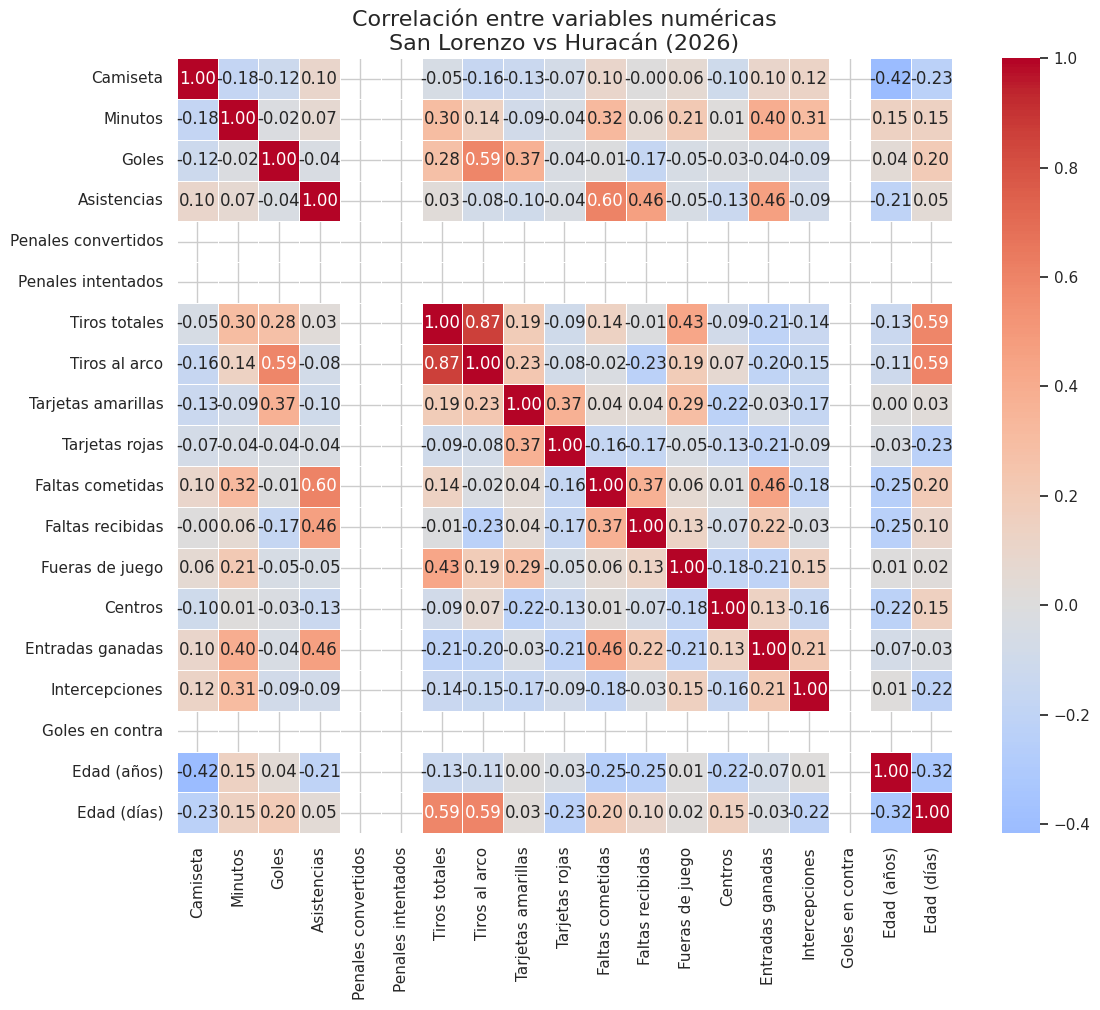

In [ ]:
# Redefinir columnas numéricas sobre df_clean (ya procesado)
columnas_numericas = df_clean.select_dtypes(include='number').columns.tolist()

plt.figure(figsize=(12, 10))
correlacion = df_clean[columnas_numericas].corr()

sns.heatmap(
    correlacion,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
)
plt.title(f'Correlación entre variables numéricas\n{EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} ({FECHA})')
plt.tight_layout()
plt.savefig('../outputs/correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Filtro de jugadores activos

Para los análisis de rendimiento trabajamos solo con jugadores que tuvieron minutos en el partido.

In [ ]:
df_activos = df_clean[df_clean['Minutos'] > 0].copy()
print(f'Jugadores con minutos jugados: {len(df_activos)} de {len(df_clean)} en el dataset')

Jugadores con minutos jugados: 29 de 29 en el dataset


### 4.4 Tiros totales por jugador

**Pregunta táctica:** ¿Quiénes generaron más situaciones de peligro ofensivo?

Los tiros totales son el indicador más directo de presencia ofensiva en el partido.

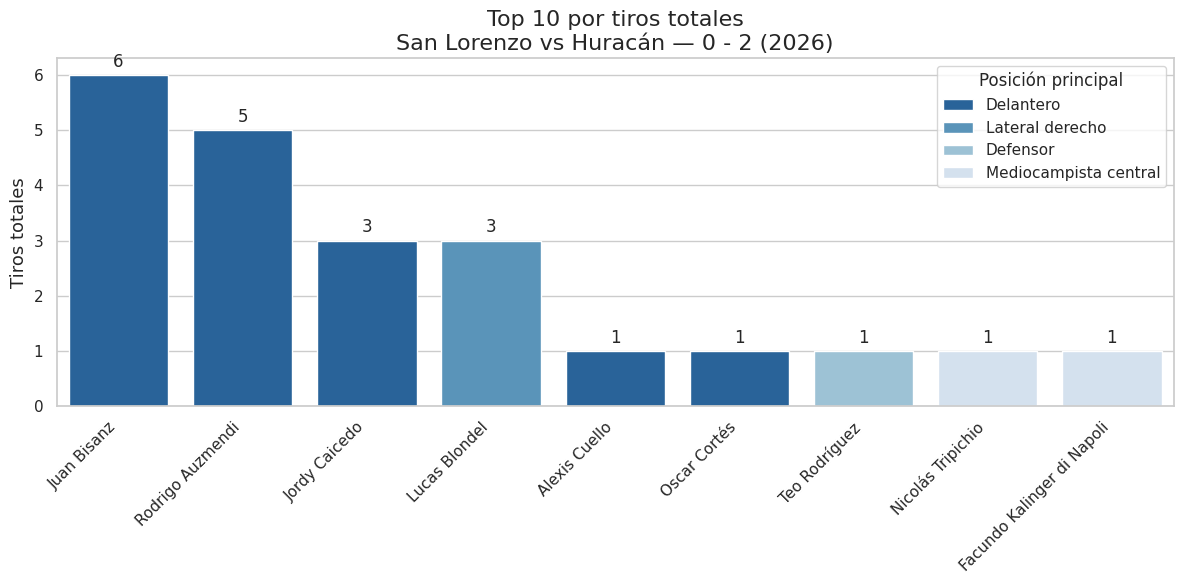

In [ ]:
df_ofensivo = df_activos[['Jugador', 'Posición principal', 'Minutos',
                            'Tiros totales', 'Tiros al arco',
                            'Goles', 'Asistencias']].copy()

# --- LA SOLUCIÓN: Filtramos para que solo queden los mayores a 0 ---
df_ofensivo = df_ofensivo[df_ofensivo['Tiros totales'] >= 1]
# -------------------------------------------------------------------

df_ofensivo = df_ofensivo.sort_values('Tiros totales', ascending=False)

plt.figure(figsize=(12, 6))
p = sns.barplot(
    data=df_ofensivo.head(10),
    x='Jugador',
    y='Tiros totales',
    hue='Posición principal',
    dodge=False,
    palette='Blues_r'
)
for container in p.containers:
    p.bar_label(container, label_type='edge', padding=3)

plt.title(f'Top 10 por tiros totales\n{EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} — {RESULTADO} ({FECHA})')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/top_tiros.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Efectividad de tiro

**Pregunta táctica:** ¿Qué tan certeros fueron los jugadores que tiraron al arco?

Un jugador puede tirar mucho pero de mala calidad, o poco pero siempre al arco.

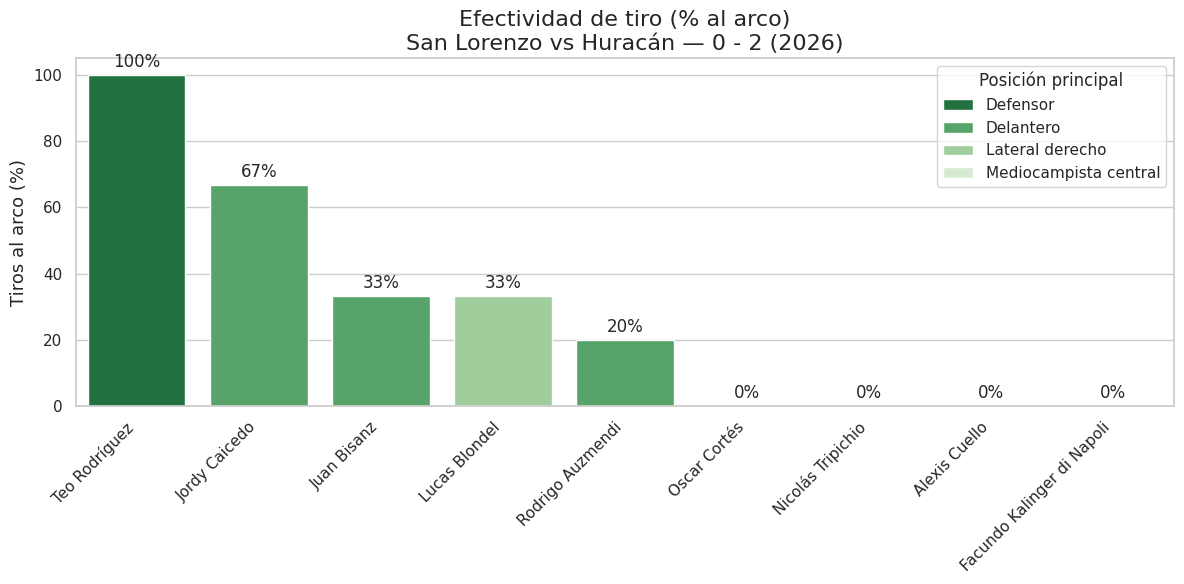

In [ ]:
df_tiros = df_activos[df_activos['Tiros totales'] > 0].copy()
df_tiros['efectividad_tiro'] = (
    df_tiros['Tiros al arco'] / df_tiros['Tiros totales'] * 100
).round(1)
df_tiros = df_tiros.sort_values('efectividad_tiro', ascending=False)

plt.figure(figsize=(12, 6))
p = sns.barplot(
    data=df_tiros,
    x='Jugador',
    y='efectividad_tiro',
    hue='Posición principal',
    dodge=False,
    palette='Greens_r'
)
for container in p.containers:
    p.bar_label(container, fmt='%.0f%%', label_type='edge', padding=3)
plt.title(f'Efectividad de tiro (% al arco)\n{EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} — {RESULTADO} ({FECHA})')
plt.ylabel('Tiros al arco (%)')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/efectividad_tiro.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.6 Contribuciones ofensivas directas (G+A)

**Pregunta táctica:** ¿Quiénes participaron directamente en los goles del partido?

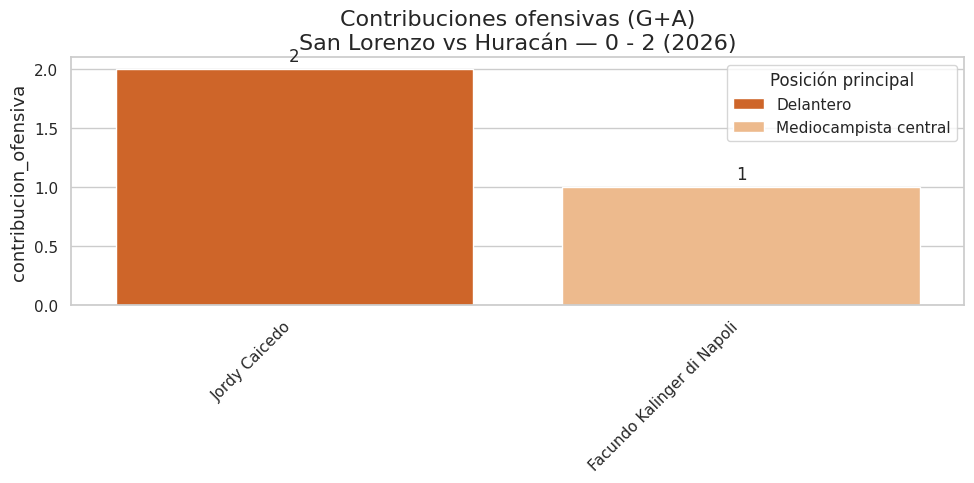

In [ ]:
df_activos['contribucion_ofensiva'] = df_activos['Goles'] + df_activos['Asistencias']
df_contrib = df_activos[df_activos['contribucion_ofensiva'] > 0].sort_values(
    'contribucion_ofensiva', ascending=False
)

if len(df_contrib) == 0:
    print('Sin goles ni asistencias en este partido')
else:
    plt.figure(figsize=(10, 5))
    p = sns.barplot(
        data=df_contrib,
        x='Jugador',
        y='contribucion_ofensiva',
        hue='Posición principal',
        dodge=False,
        palette='Oranges_r'
    )
    for container in p.containers:
        p.bar_label(container, label_type='edge', padding=3)
    plt.title(f'Contribuciones ofensivas (G+A)\n{EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} — {RESULTADO} ({FECHA})')
    plt.xlabel('')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../outputs/contribucion_ofensiva.png', dpi=150, bbox_inches='tight')
    plt.show()

### 4.7 Acciones defensivas por jugador

**Pregunta táctica:** ¿Quiénes fueron los jugadores más activos en tareas defensivas?

Combinamos entradas ganadas e intercepciones como métrica de trabajo defensivo total.

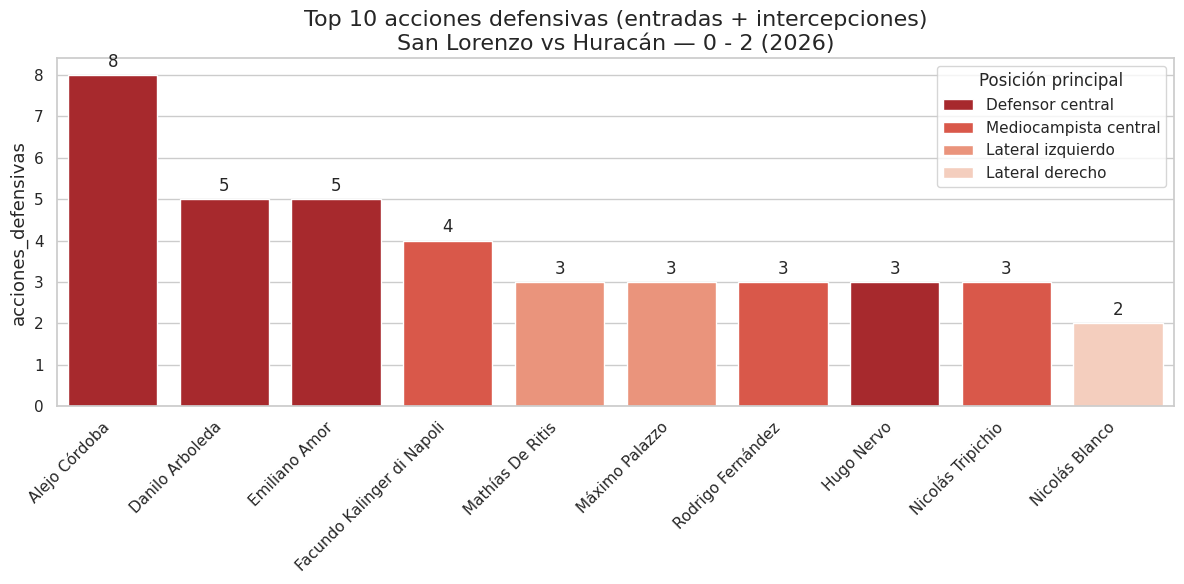

In [ ]:
df_activos['acciones_defensivas'] = (
    df_activos['Entradas ganadas'] + df_activos['Intercepciones']
)

df_def = df_activos[['Jugador', 'Posición principal', 'Minutos',
                       'Entradas ganadas', 'Intercepciones',
                       'acciones_defensivas']].sort_values(
    'acciones_defensivas', ascending=False
)

plt.figure(figsize=(12, 6))
p = sns.barplot(
    data=df_def.head(10),
    x='Jugador',
    y='acciones_defensivas',
    hue='Posición principal',
    dodge=False,
    palette='Reds_r'
)
for container in p.containers:
    p.bar_label(container, label_type='edge', padding=3)
plt.title(f'Top 10 acciones defensivas (entradas + intercepciones)\n{EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} — {RESULTADO} ({FECHA})')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/acciones_defensivas.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.8 Acciones defensivas por posición

**Pregunta táctica:** ¿Qué línea del equipo cargó más con el trabajo defensivo?

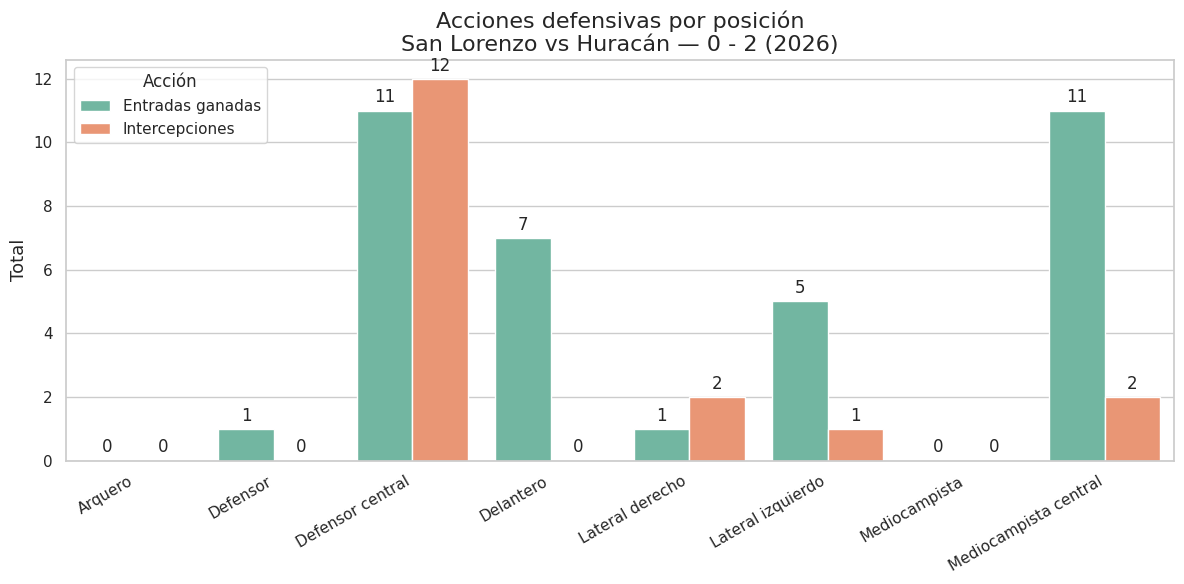

In [ ]:
df_def_pos = df_activos.groupby('Posición principal')[
    ['Entradas ganadas', 'Intercepciones']
].sum().reset_index()

df_def_pos_melt = df_def_pos.melt(
    id_vars='Posición principal',
    value_vars=['Entradas ganadas', 'Intercepciones'],
    var_name='Acción',
    value_name='Total'
)

plt.figure(figsize=(12, 6))
p = sns.barplot(
    data=df_def_pos_melt,
    x='Posición principal',
    y='Total',
    hue='Acción',
    palette='Set2'
)
for container in p.containers:
    p.bar_label(container, label_type='edge', padding=3)
plt.title(f'Acciones defensivas por posición\n{EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} — {RESULTADO} ({FECHA})')
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../outputs/defensiva_por_posicion.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.9 Minutos jugados por jugador

**Pregunta táctica:** ¿Cómo distribuyó el técnico los minutos entre los jugadores disponibles?

Las líneas de referencia marcan el entretiempo (45') y el tiempo reglamentario (90').

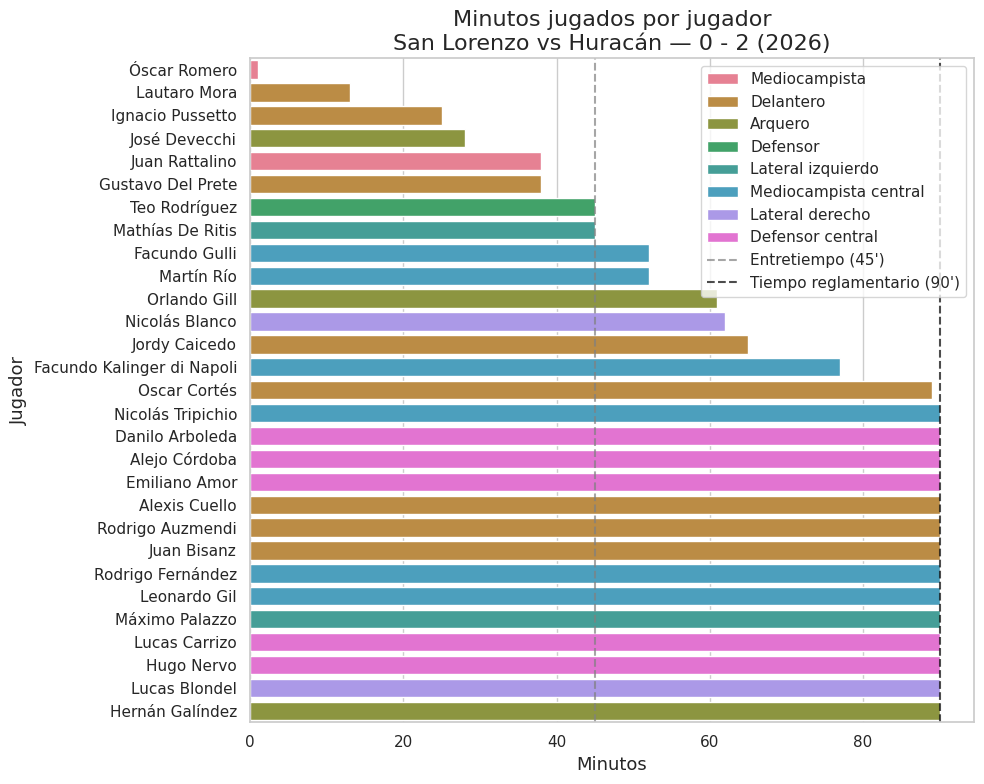

In [ ]:
df_min = df_activos.sort_values('Minutos', ascending=True)

plt.figure(figsize=(10, 8))
p = sns.barplot(
    data=df_min,
    x='Minutos',
    y='Jugador',
    hue='Posición principal',
    dodge=False,
    palette='husl'
)
plt.axvline(45, color='gray', linestyle='--', alpha=0.7, label='Entretiempo (45\')')
plt.axvline(90, color='black', linestyle='--', alpha=0.7, label='Tiempo reglamentario (90\')')
plt.title(f'Minutos jugados por jugador\n{EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} — {RESULTADO} ({FECHA})')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/minutos_jugados.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.10 Métricas per90 — Rendimiento normalizado por minutos

**Pregunta táctica:** ¿Quiénes fueron más intensos en relación a su tiempo de juego?

Normalizar por 90 minutos permite comparar titulares (90') con suplentes (20-30') en igualdad de condiciones.

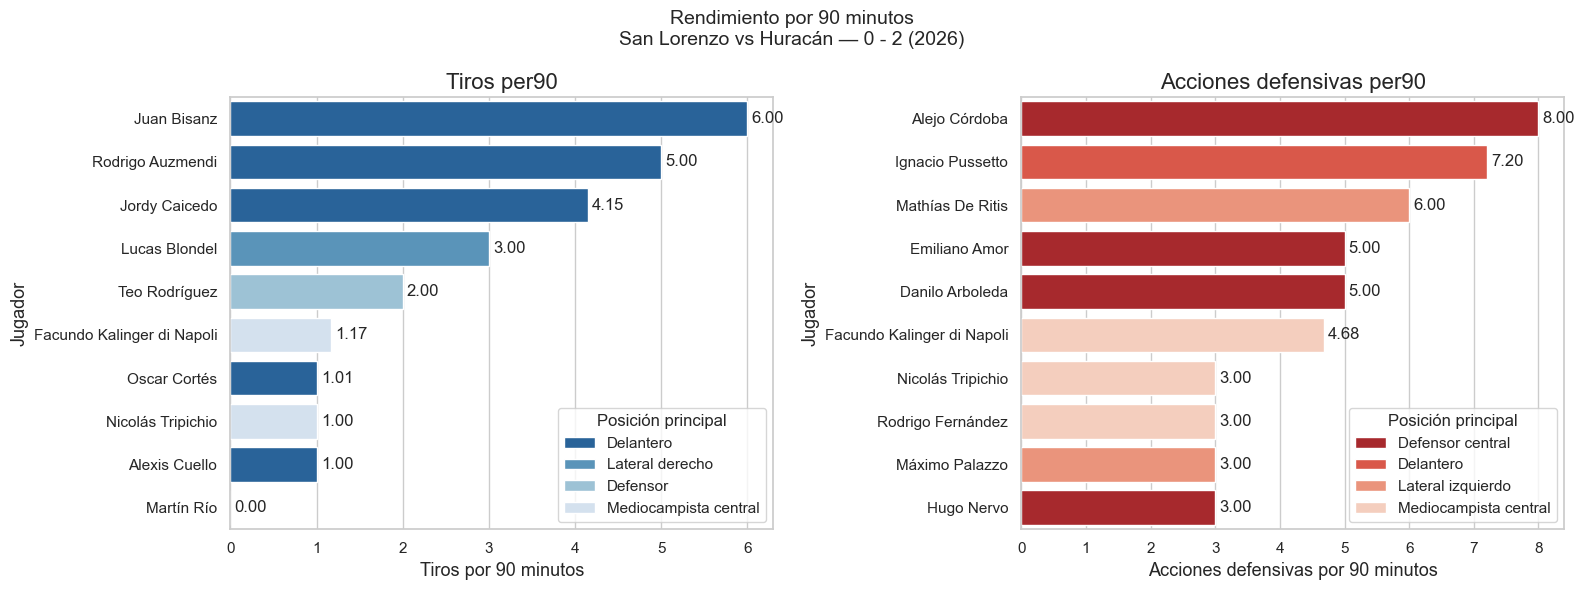

In [ ]:
df_per90 = df_activos[df_activos['Minutos'] >= 10].copy()

df_per90['tiros_per90']   = (df_per90['Tiros totales'] / df_per90['Minutos'] * 90).round(2)
df_per90['def_per90']     = (df_per90['acciones_defensivas'] / df_per90['Minutos'] * 90).round(2)
df_per90['centros_per90'] = (df_per90['Centros'] / df_per90['Minutos'] * 90).round(2)

# Gráfico — tiros per90
df_per90_sorted = df_per90.sort_values('tiros_per90', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo — tiros per90
sns.barplot(
    data=df_per90_sorted.head(10),
    x='tiros_per90',
    y='Jugador',
    hue='Posición principal',
    dodge=False,
    palette='Blues_r',
    ax=axes[0]
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', label_type='edge', padding=3)
axes[0].set_title('Tiros per90')
axes[0].set_xlabel('Tiros por 90 minutos')

# Panel derecho — acciones defensivas per90
df_def_sorted = df_per90.sort_values('def_per90', ascending=False)
sns.barplot(
    data=df_def_sorted.head(10),
    x='def_per90',
    y='Jugador',
    hue='Posición principal',
    dodge=False,
    palette='Reds_r',
    ax=axes[1]
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', label_type='edge', padding=3)
axes[1].set_title('Acciones defensivas per90')
axes[1].set_xlabel('Acciones defensivas por 90 minutos')

plt.suptitle(f'Rendimiento por 90 minutos\n{EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} — {RESULTADO} ({FECHA})', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/metricas_per90.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.11 Resumen de métricas por posición

**Pregunta táctica:** ¿Qué aportó cada línea del equipo ofensiva y defensivamente?

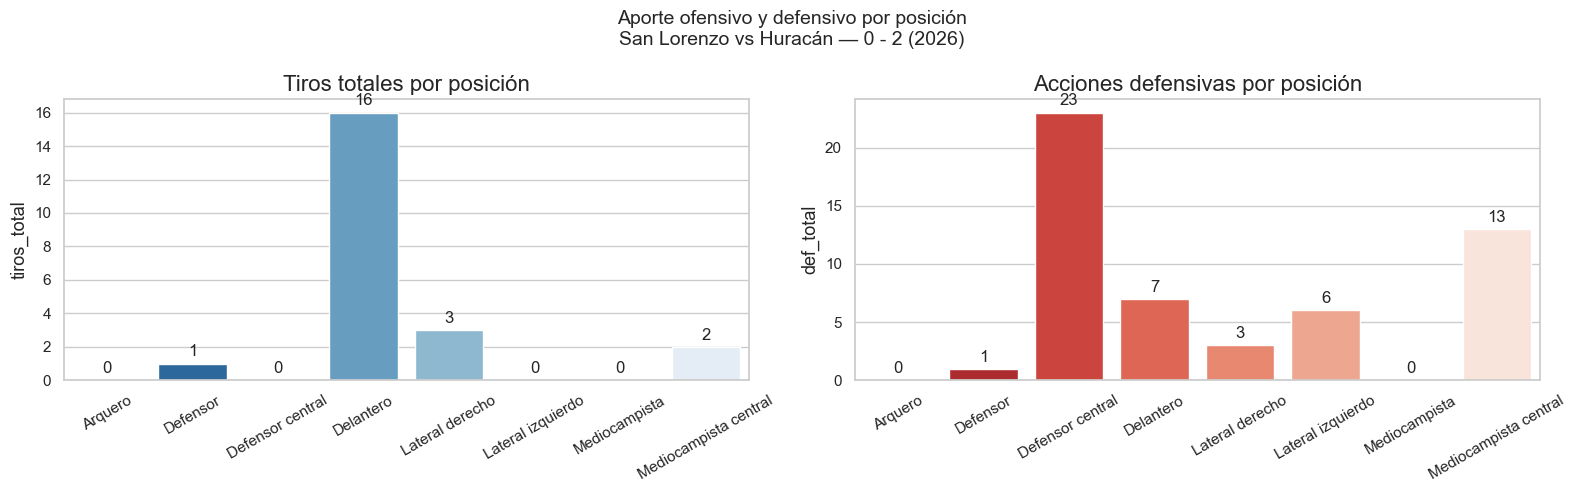


--- Tabla resumen completa ---


,Posición principal,jugadores,minutos_prom,tiros_total,tiros_arco_total,goles_total,def_total,faltas_com,faltas_rec
0,Arquero,3,59.70,0,0,0,0,0,0
1,Defensor,1,45.00,1,1,0,1,1,0
2,Defensor central,5,90.00,0,0,0,23,2,4
3,Delantero,8,62.50,16,5,2,7,8,11
4,Lateral derecho,2,76.00,3,1,0,3,3,2
5,Lateral izquierdo,2,67.50,0,0,0,6,4,2
6,Mediocampista,2,19.50,0,0,0,0,0,1
7,Mediocampista central,6,75.20,2,0,0,13,13,11


In [ ]:
metricas_por_pos = df_activos.groupby('Posición principal').agg(
    jugadores=('Jugador', 'count'),
    minutos_prom=('Minutos', 'mean'),
    tiros_total=('Tiros totales', 'sum'),
    tiros_arco_total=('Tiros al arco', 'sum'),
    goles_total=('Goles', 'sum'),
    def_total=('acciones_defensivas', 'sum'),
    faltas_com=('Faltas cometidas', 'sum'),
    faltas_rec=('Faltas recibidas', 'sum'),
).round(1).reset_index()

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ofensivo
sns.barplot(
    data=metricas_por_pos,
    x='Posición principal',
    y='tiros_total',
    hue='Posición principal',
    legend=False,
    palette='Blues_r',
    ax=axes[0]
)
for container in axes[0].containers:
    axes[0].bar_label(container, label_type='edge', padding=3)
axes[0].set_title('Tiros totales por posición')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Defensivo
sns.barplot(
    data=metricas_por_pos,
    x='Posición principal',
    y='def_total',
    hue='Posición principal',
    legend=False,
    palette='Reds_r',
    ax=axes[1]
)
for container in axes[1].containers:
    axes[1].bar_label(container, label_type='edge', padding=3)
axes[1].set_title('Acciones defensivas por posición')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle(f'Aporte ofensivo y defensivo por posición\n{EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} — {RESULTADO} ({FECHA})', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/aporte_por_posicion.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen
print('\n--- Tabla resumen completa ---')
display(metricas_por_pos)

### 4.12 Disciplina — Faltas cometidas vs recibidas

**Pregunta táctica:** ¿Hubo jugadores especialmente problemáticos o muy foulleados?

La diferencia entre faltas cometidas y recibidas puede revelar jugadores que generan roce  
o que son objetivo frecuente de la presión rival.

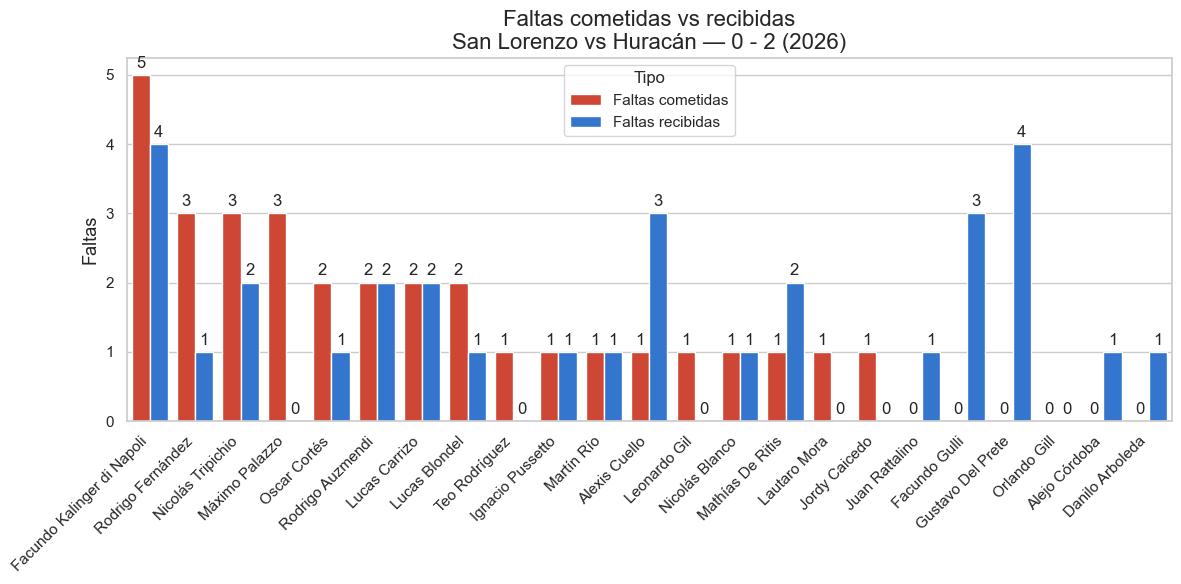

--- Tarjetas ---


,Jugador,Posición principal,Tarjetas amarillas,Tarjetas rojas
0,Rodrigo Auzmendi,Delantero,1,0
7,Mathías De Ritis,Lateral izquierdo,1,0
14,Orlando Gill,Arquero,1,1
17,Jordy Caicedo,Delantero,1,0
18,Ignacio Pussetto,Delantero,1,0
25,Lucas Carrizo,Defensor central,1,0


In [ ]:
df_disciplina = df_activos[
    (df_activos['Faltas cometidas'] > 0) |
    (df_activos['Faltas recibidas'] > 0) |
    (df_activos['Tarjetas amarillas'] > 0) |
    (df_activos['Tarjetas rojas'] > 0)
].copy().sort_values('Faltas cometidas', ascending=False)

df_disc_melt = df_disciplina[['Jugador', 'Faltas cometidas', 'Faltas recibidas']].melt(
    id_vars='Jugador',
    var_name='Tipo',
    value_name='Faltas'
)

plt.figure(figsize=(12, 6))
p = sns.barplot(
    data=df_disc_melt,
    x='Jugador',
    y='Faltas',
    hue='Tipo',
    palette={'Faltas cometidas': '#e8341a', 'Faltas recibidas': '#1a73e8'}
)
for container in p.containers:
    p.bar_label(container, label_type='edge', padding=3)
plt.title(f'Faltas cometidas vs recibidas\n{EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} — {RESULTADO} ({FECHA})')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/disciplina.png', dpi=150, bbox_inches='tight')
plt.show()

# Tarjetas
tarjetas = df_activos[
    (df_activos['Tarjetas amarillas'] > 0) | (df_activos['Tarjetas rojas'] > 0)
][['Jugador', 'Posición principal', 'Tarjetas amarillas', 'Tarjetas rojas']]

if len(tarjetas) == 0:
    print('Sin tarjetas en este partido')
else:
    print('--- Tarjetas ---')
    display(tarjetas)

### 4.13 Perfil individual de jugador

**Pregunta táctica:** ¿Cómo fue el partido de Facundo Kalinger en comparación con el promedio de su posición?

Los indicadores ▲ / ▼ / ─ muestran si el jugador estuvo por encima, por debajo o igual al promedio de su posición.

In [ ]:
def perfil_jugador(df: pd.DataFrame, nombre: str) -> None:
    """
    Muestra el perfil completo de un jugador en el partido.
    Compara sus métricas con el promedio de su posición.
    Indicadores: ▲ por encima | ▼ por debajo | ─ igual
    """
    jugador = df[df['Jugador'].str.contains(nombre, case=False, na=False)]

    if jugador.empty:
        print(f"Jugador '{nombre}' no encontrado")
        return

    jugador = jugador.iloc[0]
    posicion = jugador['Posición principal']
    promedio_pos = df[df['Posición principal'] == posicion].select_dtypes(include='number').mean()

    metricas = ['Minutos', 'Tiros totales', 'Tiros al arco', 'Goles',
                'Asistencias', 'Entradas ganadas', 'Intercepciones',
                'Faltas cometidas', 'Faltas recibidas', 'Centros']

    metricas_presentes = [m for m in metricas if m in df.columns]

    print(f"\n{'='*60}")
    print(f"PERFIL: {jugador['Jugador']} | {posicion} | {jugador['Minutos']} min")
    print(f"Partido: {EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} — {RESULTADO} ({FECHA})")
    print(f"{'='*60}")
    print(f"{'Métrica':<25} {'Valor':>8} {'Prom. posición':>15}  Ind.")
    print(f"{'-'*60}")
    for m in metricas_presentes:
        if m in jugador.index and m in promedio_pos.index:
            diff = jugador[m] - promedio_pos[m]
            indicador = '▲' if diff > 0 else ('▼' if diff < 0 else '─')
            print(f"{m:<25} {jugador[m]:>8.0f} {promedio_pos[m]:>15.1f}  {indicador}")
    print(f"{'='*60}")
    print('▲ por encima del promedio | ▼ por debajo | ─ igual')

perfil_jugador(df_activos, 'Facundo Kalinger')


PERFIL: Facundo Kalinger di Napoli | Mediocampista central | 77 min
Partido: San Lorenzo vs Huracán — 0 - 2 (2026)
Métrica                      Valor  Prom. posición  Ind.
------------------------------------------------------------
Minutos                         77            75.2  ▲
Tiros totales                    1             0.3  ▲
Tiros al arco                    0             0.0  ─
Goles                            0             0.0  ─
Asistencias                      1             0.2  ▲
Entradas ganadas                 4             1.8  ▲
Intercepciones                   0             0.3  ▼
Faltas cometidas                 5             2.2  ▲
Faltas recibidas                 4             1.8  ▲
Centros                          0             2.2  ▼
▲ por encima del promedio | ▼ por debajo | ─ igual


NameError: name 'OUTPUT_PATH' is not defined

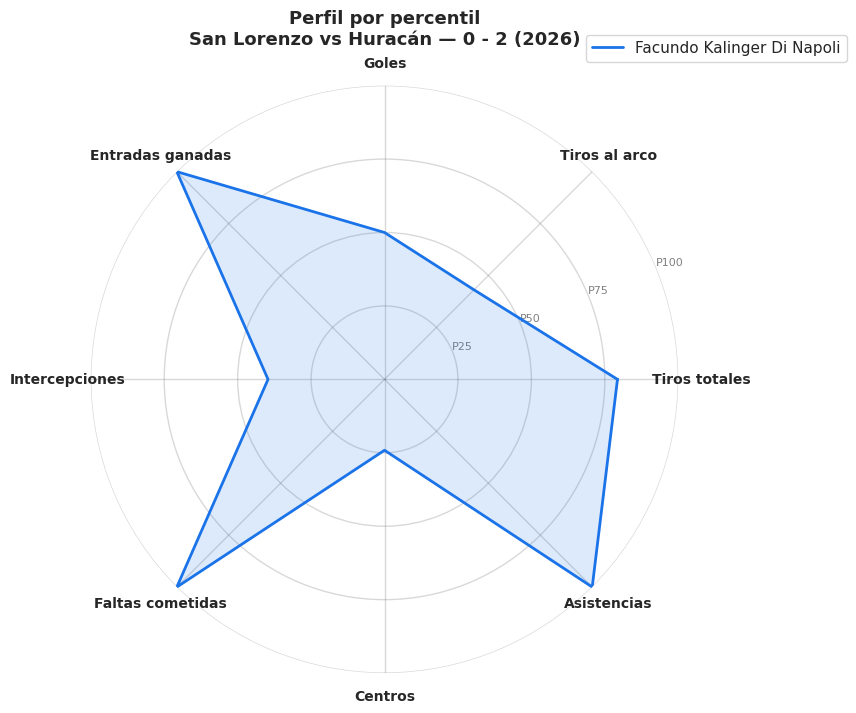

In [ ]:
import matplotlib.patches as mpatches
import numpy as np

def radar_jugadores(df: pd.DataFrame, jugadores: list, metricas: list) -> None:
    """
    Radar chart comparativo para múltiples jugadores.
    Las métricas se normalizan por percentil (0-100) dentro del dataset.
    """
    # Normalizar métricas a percentil
    df_norm = df.copy()
    for m in metricas:
        if m in df_norm.columns:
            df_norm[m] = df_norm[m].rank(pct=True) * 100

    N = len(metricas)
    angulos = [n / float(N) * 2 * np.pi for n in range(N)]
    angulos += angulos[:1]

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
    colores = ['#1a73e8', '#e8341a', '#34a853', '#fbbc04', '#9c27b0']

    for idx, nombre in enumerate(jugadores):
        fila = df_norm[df_norm['Jugador'].str.contains(nombre, case=False, na=False)]
        if fila.empty:
            print(f"Jugador '{nombre}' no encontrado")
            continue
        fila = fila.iloc[0]
        valores = [fila[m] if m in fila.index else 0 for m in metricas]
        valores += valores[:1]
        color = colores[idx % len(colores)]
        ax.plot(angulos, valores, linewidth=2, linestyle='solid', color=color, label=nombre)
        ax.fill(angulos, valores, alpha=0.15, color=color)

    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(metricas, size=10, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75, 100])
    ax.set_yticklabels(['P25', 'P50', 'P75', 'P100'], size=8, color='gray')
    ax.grid(color='gray', alpha=0.3)
    ax.spines['polar'].set_visible(False)

    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
    plt.title(
        f'Perfil por percentil\n{EQUIPO_LOCAL} vs {EQUIPO_VISITANTE} — {RESULTADO} ({FECHA})',
        size=13, pad=30, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_PATH}/{PARTIDO_ID}_radar.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Uso — reemplazar con los jugadores y métricas relevantes del partido ──
METRICAS_RADAR = [
    'Tiros totales', 'Tiros al arco', 'Goles',
    'Entradas ganadas', 'Intercepciones', 'Faltas cometidas',
    'Centros', 'Asistencias'
]

JUGADORES_RADAR = [
    'Facundo Kalinger Di Napoli',
]
# ─────────────────────────────────────────────────────────────────────────

radar_jugadores(df_activos, JUGADORES_RADAR, METRICAS_RADAR)